Khởi tạo thử viện & config

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6) # Kích thước biểu đồ chuẩn
plt.rcParams['axes.titlesize'] = 14      # Cỡ chữ tiêu đề

1.DESCRIPTIVE STATISTICS:

In [29]:
# Load data (Lùi 1 cấp từ thư mục analysis/ ra gốc, rồi vào data/)
df = pd.read_csv('../data/dataset_after_categorical_imputing.csv')

print("1. Kích thước dữ liệu (Dòng, Cột):", df.shape)
print("\n2. Thông tin các cột và kiểu dữ liệu:")
df.info()

print("\n3. Thống kê mô tả các biến số (Kinh nghiệm, Lương):")
display(df[['exp_years', 'salary_avg']].describe())

print("\n4. Đếm số lượng theo Cấp bậc (Job Level):")
display(df['job_level'].value_counts(dropna=False))

1. Kích thước dữ liệu (Dòng, Cột): (5661, 18)

2. Thông tin các cột và kiểu dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 5661 entries, 0 to 5660
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              5661 non-null   str    
 1   job_title        5661 non-null   str    
 2   tech_stack       5661 non-null   str    
 3   language_req     5661 non-null   int64  
 4   is_manager       5661 non-null   int64  
 5   work_method      5661 non-null   str    
 6   contract_type    5661 non-null   str    
 7   salary_min       2140 non-null   float64
 8   salary_max       2353 non-null   float64
 9   exp_years        5661 non-null   float64
 10  location         5661 non-null   str    
 11  job_level        5661 non-null   float64
 12  source           5661 non-null   str    
 13  company_name     5661 non-null   str    
 14  education_level  5661 non-null   str    
 15  is_shift_work    5661 non-null  

,exp_years,salary_avg
count,5661.000000,2399.000000
mean,2.154743,25.322078
std,1.495987,24.187465
min,0.000000,0.312500
25%,1.000000,13.500000
50%,2.000000,20.000000
75%,3.000000,32.500000
max,12.000000,650.000000



4. Đếm số lượng theo Cấp bậc (Job Level):


job_level
2.0    3864
3.0    1087
4.0     291
0.0     248
1.0     124
5.0      47
Name: count, dtype: int64

2.UNIVARIATE ANALYSIS:

C:\Users\ndhoa\AppData\Local\Temp\ipykernel_19048\1164007368.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='job_level', order=df['job_level'].value_counts().index, ax=axes[1, 0], palette='viridis')
C:\Users\ndhoa\AppData\Local\Temp\ipykernel_19048\1164007368.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[1, 1], palette='magma')
C:\Users\ndhoa\AppData\Local\Temp\ipykernel_19048\1164007368.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_skills.values

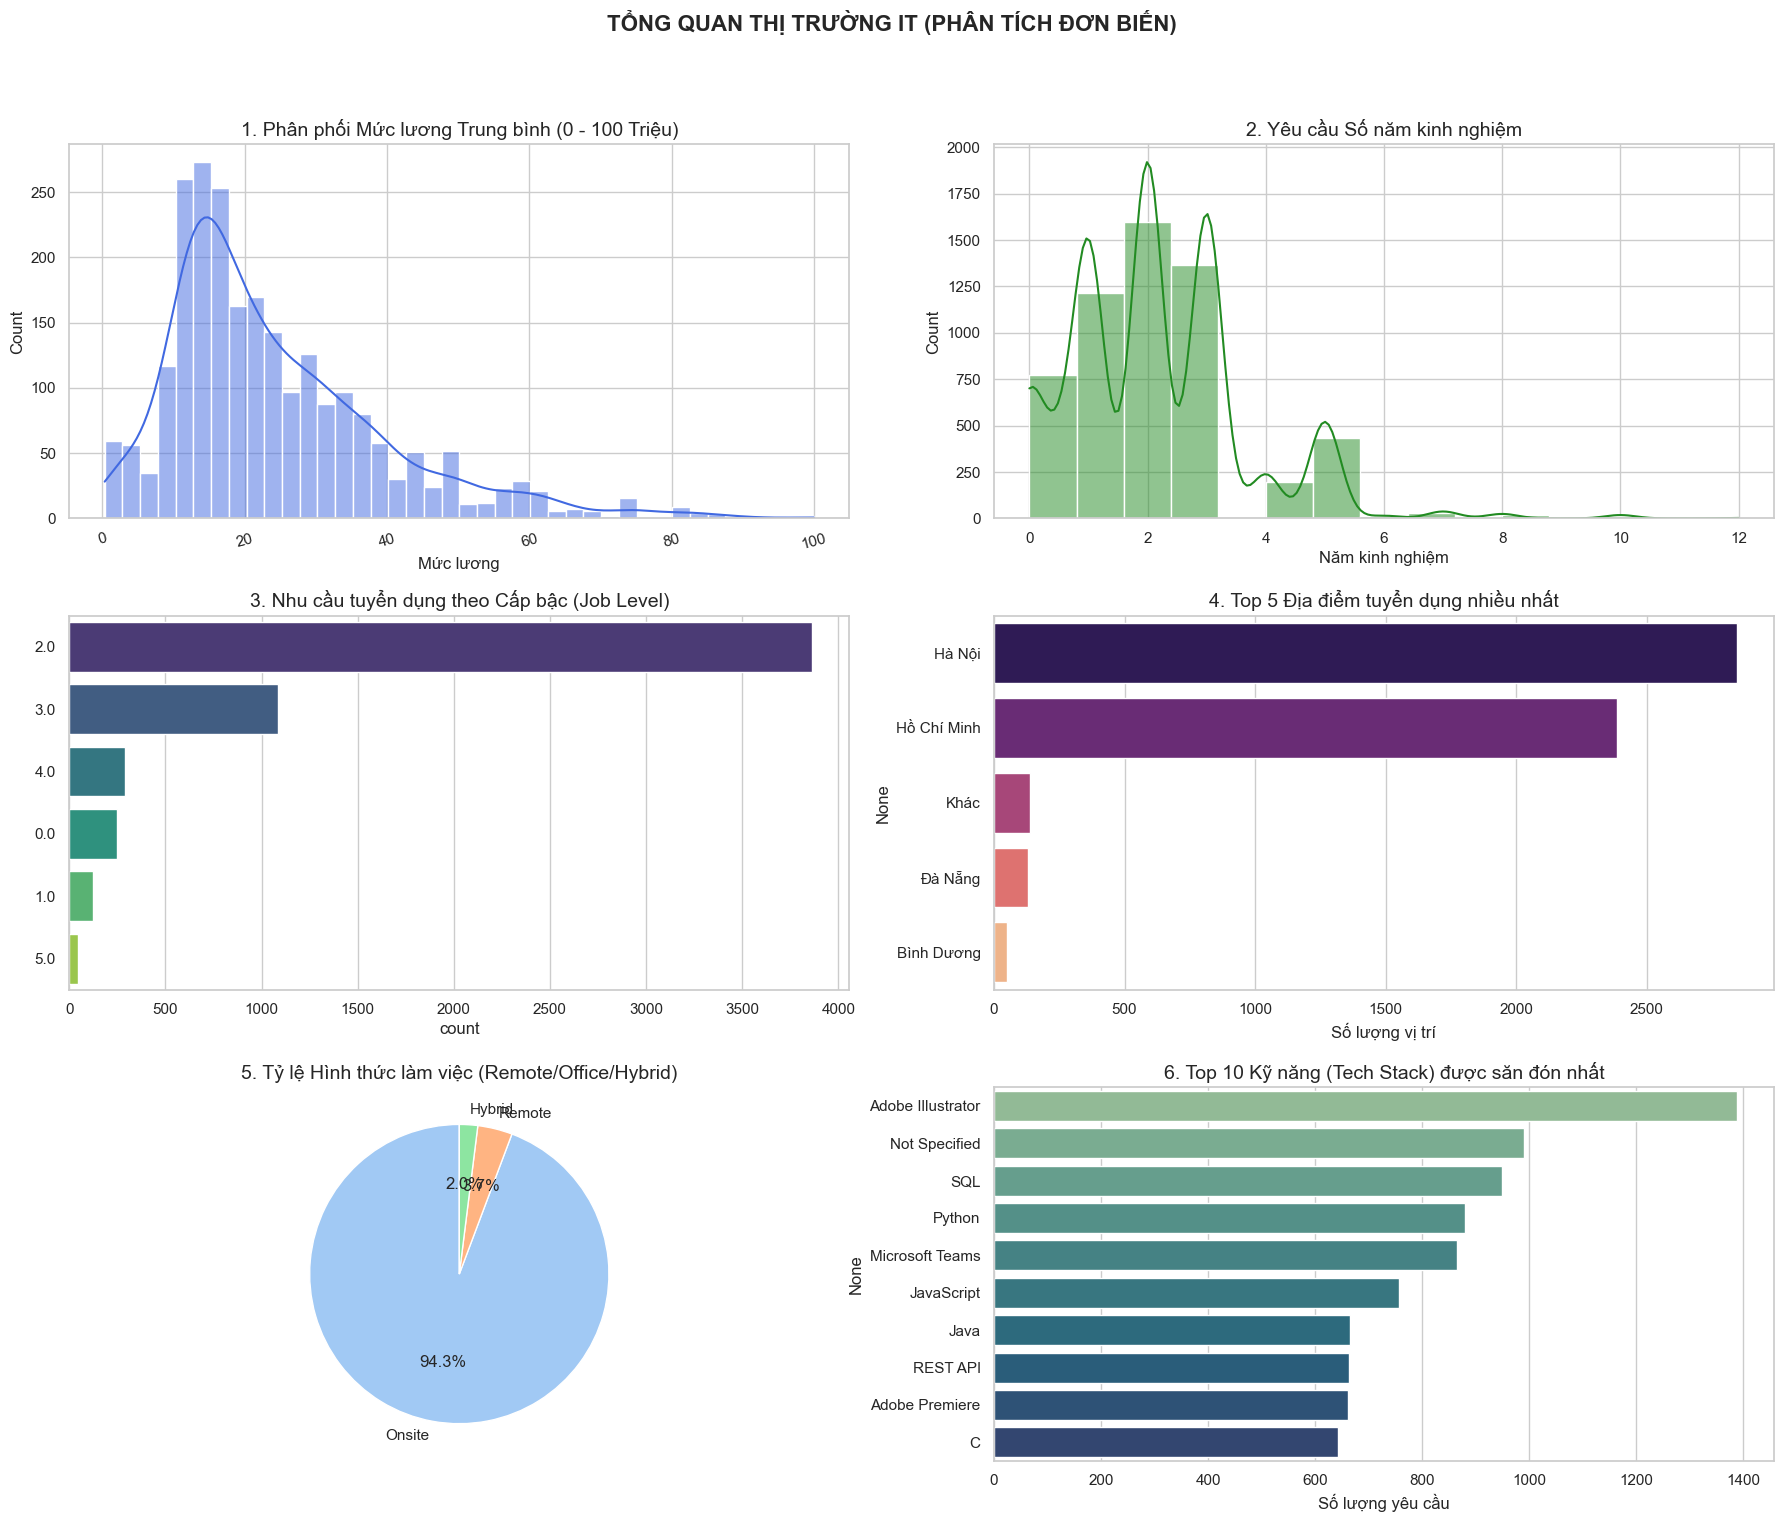

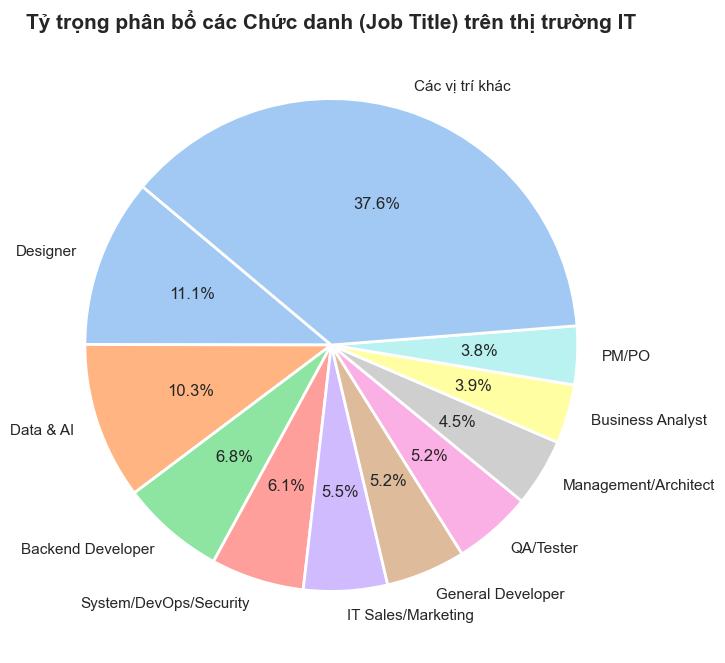

In [30]:
# MỞ RỘNG: Phân tích Đơn biến (Univariate Analysis) - Đã cập nhật xử lý Location
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pandas as pd

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('TỔNG QUAN THỊ TRƯỜNG IT (PHÂN TÍCH ĐƠN BIẾN)', fontsize=16, fontweight='bold')

# 1. Phân phối Lương (Histogram) - Giới hạn 0 đến 100 triệu
# Lọc dữ liệu trong khoảng 0 - 100tr để biểu đồ chi tiết hơn
limit_100tr = 100 # Thay bằng 100 nếu data của bạn tính theo đơn vị "triệu"
salary_filtered = df[(df['salary_avg'] > 0) & (df['salary_avg'] <= limit_100tr)]['salary_avg']

sns.histplot(salary_filtered, bins=40, kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('1. Phân phối Mức lương Trung bình (0 - 100 Triệu)')
axes[0, 0].set_xlabel('Mức lương')

# Tùy chỉnh hiển thị trục X để không bị dính chữ (nếu số quá dài)
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Phân phối Năm kinh nghiệm (Histogram)
sns.histplot(df['exp_years'].dropna(), bins=15, kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('2. Yêu cầu Số năm kinh nghiệm')
axes[0, 1].set_xlabel('Năm kinh nghiệm')

# 3. Nhu cầu theo Cấp bậc (Bar Chart)
sns.countplot(data=df, y='job_level', order=df['job_level'].value_counts().index, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('3. Nhu cầu tuyển dụng theo Cấp bậc (Job Level)')
axes[1, 0].set_ylabel('')

# 4. Phân bổ Địa điểm làm việc (Bar Chart - Đã xử lý List)
all_locations = []
for loc in df['location'].dropna():
    if isinstance(loc, str):
        if loc.startswith('['):
            try:
                parsed = ast.literal_eval(loc)
                all_locations.extend([str(l).strip() for l in parsed])
            except:
                pass
        else:
            all_locations.extend([l.strip() for l in loc.split(',')])
    elif isinstance(loc, list):
        all_locations.extend([str(l).strip() for l in loc])

top_locations = pd.Series(all_locations).value_counts().head(5)
sns.barplot(x=top_locations.values, y=top_locations.index, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('4. Top 5 Địa điểm tuyển dụng nhiều nhất')
axes[1, 1].set_xlabel('Số lượng vị trí')

# 5. Hình thức làm việc (Pie Chart)
work_method_counts = df['work_method'].value_counts()
axes[2, 0].pie(work_method_counts, labels=work_method_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[2, 0].set_title('5. Tỷ lệ Hình thức làm việc (Remote/Office/Hybrid)')

# 6. Top 10 Kỹ năng Tech Stack (Bar Chart ngang)
all_skills = []
for skills in df['tech_stack'].dropna():
    if isinstance(skills, str):
        if skills.startswith('['):
            try:
                parsed = ast.literal_eval(skills)
                all_skills.extend([str(s).strip() for s in parsed])
            except:
                pass
        else:
            all_skills.extend([s.strip() for s in skills.split(',')])
    elif isinstance(skills, list):
        all_skills.extend([str(s).strip() for s in skills])

top_10_skills = pd.Series(all_skills).value_counts().head(10)
sns.barplot(x=top_10_skills.values, y=top_10_skills.index, ax=axes[2, 1], palette='crest')
axes[2, 1].set_title('6. Top 10 Kỹ năng (Tech Stack) được săn đón nhất')
axes[2, 1].set_xlabel('Số lượng yêu cầu')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# 1. Tính tổng số lượng của từng chức danh
job_counts = df['job_category'].value_counts()

# 2. Lấy Top 5 chức danh phổ biến nhất
top_10_jobs = job_counts.head(10)

# 3. Gộp toàn bộ các chức danh còn lại thành nhóm "Các vị trí khác"
others_count = job_counts.iloc[5:].sum()
others_series = pd.Series([others_count], index=['Các vị trí khác'])

# 4. Hợp nhất dữ liệu để vẽ biểu đồ tròn
pie_data = pd.concat([top_10_jobs, others_series])

# 5. Vẽ biểu đồ Pie Chart
plt.figure(figsize=(10, 8))
# Dùng dải màu pastel cho dịu mắt, thêm viền trắng phân cách các miếng cắt
colors = sns.color_palette('pastel')[0:len(pie_data)]
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140, 
        colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Tỷ trọng phân bổ các Chức danh (Job Title) trên thị trường IT', fontsize=15, fontweight='bold')
plt.show()

3.BIVARIATE ANALYSIS:

C:\Users\ndhoa\AppData\Local\Temp\ipykernel_19048\635420986.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_salary, x='job_level', y='salary_avg', ax=axes[0, 0], palette='Set2', showfliers=False)
C:\Users\ndhoa\AppData\Local\Temp\ipykernel_19048\635420986.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_locs, x='location_list', y='salary_avg', ax=axes[1, 0], palette='magma', showfliers=False)


C:\Users\ndhoa\AppData\Local\Temp\ipykernel_19048\635420986.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_categories, x='salary_avg', y='job_category', ax=axes[2, 0], palette='Set3', showfliers=False)


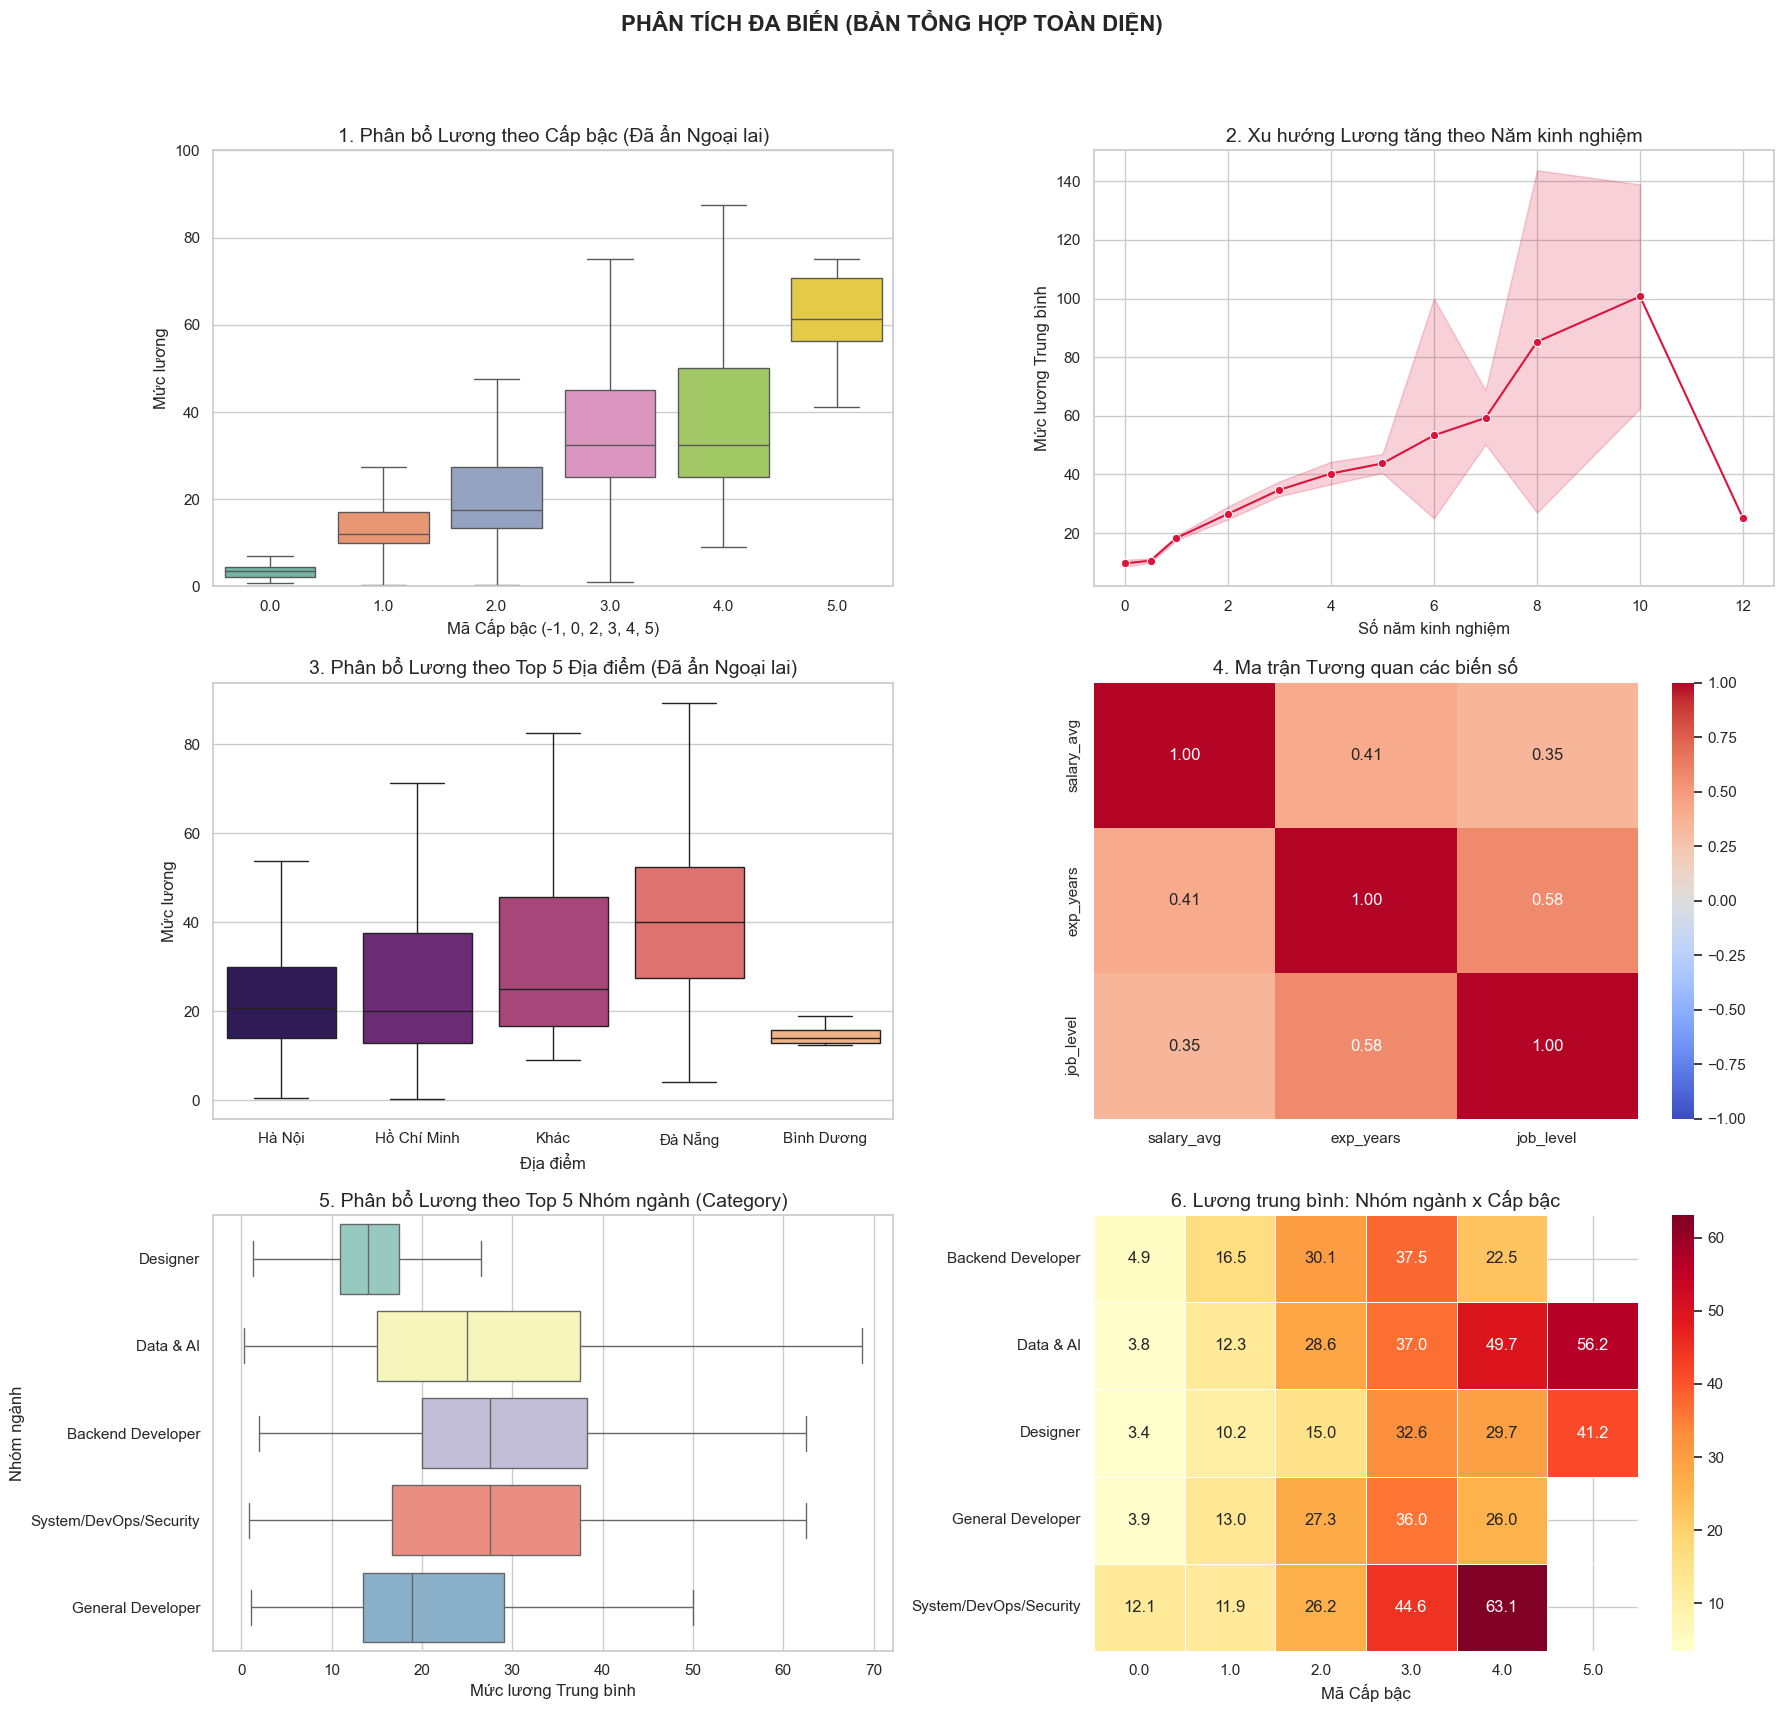

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pandas as pd
import numpy as np

# Lưới 3x2 (6 biểu đồ)
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('PHÂN TÍCH ĐA BIẾN (BẢN TỔNG HỢP TOÀN DIỆN)', fontsize=16, fontweight='bold')

# Lọc bỏ các dòng thiếu lương
df_salary = df.dropna(subset=['salary_avg']).copy()

# Giới hạn dữ liệu để vẽ đẹp hơn (Chỉ lấy kinh nghiệm <= 15 năm)
df_salary = df_salary[df_salary['exp_years'] <= 15]

# --- 1. Cấp bậc vs Lương ---
sns.boxplot(data=df_salary, x='job_level', y='salary_avg', ax=axes[0, 0], palette='Set2', showfliers=False)
axes[0, 0].set_title('1. Phân bổ Lương theo Cấp bậc (Đã ẩn Ngoại lai)')
axes[0, 0].set_xlabel('Mã Cấp bậc (-1, 0, 2, 3, 4, 5)')
axes[0, 0].set_ylabel('Mức lương')
axes[0, 0].set_ylim(0, 100) 

# --- 2. Kinh nghiệm vs Lương ---
sns.lineplot(data=df_salary, x='exp_years', y='salary_avg', ax=axes[0, 1], color='crimson', marker='o')
axes[0, 1].set_title('2. Xu hướng Lương tăng theo Năm kinh nghiệm')
axes[0, 1].set_xlabel('Số năm kinh nghiệm')
axes[0, 1].set_ylabel('Mức lương Trung bình')

# --- 3. Địa điểm vs Lương ---
def parse_location(loc):
    if isinstance(loc, str):
        if loc.startswith('['):
            try: return [str(x).strip() for x in ast.literal_eval(loc)]
            except: return []
        return [x.strip() for x in loc.split(',')]
    elif isinstance(loc, list):
        return [str(x).strip() for x in loc]
    return []

df_explode = df_salary.copy()
df_explode['location_list'] = df_explode['location'].apply(parse_location)
df_explode = df_explode.explode('location_list')
top_5_locs = df_explode['location_list'].value_counts().head(5).index
df_top_locs = df_explode[df_explode['location_list'].isin(top_5_locs)]

sns.boxplot(data=df_top_locs, x='location_list', y='salary_avg', ax=axes[1, 0], palette='magma', showfliers=False)
axes[1, 0].set_title('3. Phân bổ Lương theo Top 5 Địa điểm (Đã ẩn Ngoại lai)')
axes[1, 0].set_xlabel('Địa điểm')
axes[1, 0].set_ylabel('Mức lương')

# --- 4. Ma trận tương quan ---
numeric_cols = ['salary_avg', 'exp_years', 'job_level']
numeric_cols = [c for c in numeric_cols if c in df_salary.columns]

corr = df_salary[numeric_cols].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1], vmin=-1, vmax=1)
axes[1, 1].set_title('4. Ma trận Tương quan các biến số')

# --- 5. Nhóm ngành (Job Category) vs Lương (Boxplot) ---
top_5_categories = df_salary['job_category'].value_counts().nlargest(5).index
df_top_categories = df_salary[df_salary['job_category'].isin(top_5_categories)]

sns.boxplot(data=df_top_categories, x='salary_avg', y='job_category', ax=axes[2, 0], palette='Set3', showfliers=False)
axes[2, 0].set_title('5. Phân bổ Lương theo Top 5 Nhóm ngành (Category)')
axes[2, 0].set_xlabel('Mức lương Trung bình')
axes[2, 0].set_ylabel('Nhóm ngành')

# --- 6. Nhóm ngành x Cấp bậc vs Lương (Heatmap) ---
pivot_salary = df_top_categories.pivot_table(values='salary_avg', index='job_category', columns='job_level', aggfunc='mean')
sns.heatmap(pivot_salary, annot=True, fmt=".1f", cmap='YlOrRd', ax=axes[2, 1], linewidths=.5)
axes[2, 1].set_title('6. Lương trung bình: Nhóm ngành x Cấp bậc')
axes[2, 1].set_xlabel('Mã Cấp bậc')
axes[2, 1].set_ylabel('') # Ẩn tên trục Y vì đã có ở biểu đồ 5

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()